# Dysbiosis Calls and Defense Score (Recalled Genera)

Updated version of `Local_analysis/Followup_analyses_after_Luke_talk/Immunity_and_defense_score/check_dysbiosis_in_circadian_samples.ipynb`.

**Dysbiosis definition (recalled genera):**
- **Rare genera:** present in < 10% of seasonal plant samples, as in `core_and_rare_species_definitions_and_temporal_patterns.ipynb`. Genera seen only in circadian samples (0% seasonal prevalence) also count as rare.
- **Core genera:** present in > 80% of seasonal plant samples.
- **Dysbiotic:** a sample whose rare genera make up more than `rare_genera_abundance_threshold` percent of its reads.

Merging species into genera leaves much less abundance in rare taxa than the old species-level table, so the old 9.5% cutoff calls no samples. The threshold plot below shows how the number of dysbiotic samples changes with the cutoff. The default of 1% calls about as many samples as the old species-level rule.

This notebook saves the calls to `Generated_data/dysbiosis_calls_recalled_genera.csv`. The PCA and differential-expression notebooks in this folder read that file, so **change the threshold here and re-run the three notebooks in order**.

Luke's genus-level calls (`lic_16S_gen_dysbiosis.csv`) are only used for comparison, not for the calls.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skbio.diversity.alpha import shannon
from scipy.stats import zscore
from scipy.stats import ttest_ind

In [2]:
###Define Thresholds
rare_genera_definition_threshold = 0.1  # prevalence in seasonal plant samples
core_genera_definition_threshold = 0.8
rare_genera_abundance_threshold = 1.0  # % of the sample's reads in rare genera

In [3]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)

## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### For remaining duplicated sampIDs, drop the transcriptome with fewer total reads
double_duplicates = (
    trimmed_metadata.loc[trimmed_metadata.duplicated(subset="sampID", keep=False)]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
print("Transcriptomes after removing replicates:", len(trimmed_metadata))
defense_gene_list = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/load_correlated_genes_union_GO_and_FLG_plates_1_to_5.csv"
)

Transcriptomes after removing replicates: 432


## Rare and core genera

In [4]:
microbiome_abundance = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Sept_2026_recalled_genera/lic_16S_gen_rab_clean.csv"
)
plant_microbiome = microbiome_abundance.loc[microbiome_abundance["sample.type"] == "plant"]

# Sample x genus abundance as % of each sample's reads (absent genera = 0)
genus_abundance_matrix = pd.pivot_table(
    plant_microbiome,
    values="Abundance",
    index="Sample",
    columns="Genus",
    aggfunc="sum",
    fill_value=0,
)
genus_abundance_matrix = (
    genus_abundance_matrix.div(genus_abundance_matrix.sum(axis=1), axis=0) * 100
)

seasonal_samples = plant_microbiome.loc[
    plant_microbiome["seascirc"] == "seasonal", "Sample"
].unique()
seasonal_prevalence = (genus_abundance_matrix.loc[seasonal_samples] > 0).mean()

rare_genera = seasonal_prevalence.index[
    seasonal_prevalence < rare_genera_definition_threshold
].tolist()
core_genera = seasonal_prevalence.index[
    seasonal_prevalence > core_genera_definition_threshold
].tolist()

print("Plant microbiome samples:", genus_abundance_matrix.shape[0])
print("Seasonal samples (prevalence denominator):", len(seasonal_samples))
print(f"Rare genera: {len(rare_genera)} ({(seasonal_prevalence[rare_genera] == 0).sum()} only seen in circadian samples)")
print(f"Core genera: {len(core_genera)}")

Plant microbiome samples: 428
Seasonal samples (prevalence denominator): 222
Rare genera: 160 (15 only seen in circadian samples)
Core genera: 36


In [5]:
present = genus_abundance_matrix > 0
sample_summary = pd.DataFrame(
    {
        "shannon_diversity": genus_abundance_matrix.apply(
            lambda row: shannon(row.to_numpy()), axis=1
        ),
        "total_genera_present": present.sum(axis=1),
        "n_core_genera_present": present[core_genera].sum(axis=1),
        "has_rare_genera": present[rare_genera].any(axis=1),
        "lacking_core_genera": ~present[core_genera].all(axis=1),
        "rare_genera_total_abund": genus_abundance_matrix[rare_genera].sum(axis=1),
    }
)

# Add columns to metadata using the sampID column (not the index). Transcriptomes
# without a microbiome profile get 0 rare abundance, as in the original.
for column in sample_summary.columns:
    trimmed_metadata[column] = trimmed_metadata["sampID"].map(sample_summary[column])
print(
    "Transcriptomes without a microbiome profile:",
    trimmed_metadata["rare_genera_total_abund"].isna().sum(),
)
trimmed_metadata["rare_genera_total_abund"] = trimmed_metadata[
    "rare_genera_total_abund"
].fillna(0.0)

trimmed_metadata[["sampID", "timepoint"] + sample_summary.columns.tolist()]

Transcriptomes without a microbiome profile: 4


,sampID,timepoint,shannon_diversity,total_genera_present,n_core_genera_present,has_rare_genera,lacking_core_genera,rare_genera_total_abund
filename,,,,,,,,
A2450525897_n01_LICRNA01_A01,LIC001,t01,3.223981,91.0,36.0,True,False,0.886541
A2450525897_n01_LICRNA01_B01,LIC002,t01,3.284777,78.0,33.0,True,True,0.832287
A2450525897_n01_LICRNA01_C01,LIC003,t01,3.251388,82.0,36.0,True,False,0.667085
A2450525897_n01_LICRNA01_E01,LIC005,t01,2.636913,66.0,35.0,True,True,0.756112
A2450525897_n01_LICRNA01_F01,LIC006,t01,2.503066,60.0,33.0,True,True,0.069065
...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,LIC542,c1_t13,3.293857,70.0,36.0,True,False,0.383538
A2534491401_n01_LICRNA05_E12,LIC495,c1_t09,2.577783,57.0,31.0,True,True,0.072936
A2534491401_n01_LICRNA05_F12,LIC421,c1_t04,2.662836,54.0,35.0,True,True,0.476948


## Picking the rare-genera abundance threshold

Number of transcriptome samples called dysbiotic at each rare-genera abundance cutoff. The dashed horizontal line is the number of samples called dysbiotic by the old species-level rule (rare species = present in ≤ 37 of 372 samples, dysbiotic = > 9.5% abundance in rare species), rebuilt here on the same transcriptome samples. The orange line shows how many of the new calls were also dysbiotic under the old rule.

Note: the rebuilt old rule calls 51 samples, not the 58 in the original notebook. The original merged the microbiome table with the transcriptome metadata on `sampID`, which duplicated the microbiome rows of samples with more than one transcriptome and inflated their rare abundance.

In [6]:
# Old species-level calls, rebuilt as in the original notebook
old_microbiome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
old_species_table = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/species_core_results.csv"
)
old_rare_species = set(
    old_species_table.loc[old_species_table["n_samples_present"] <= 37, "Species"]
)
old_rare_abund = (
    old_microbiome.loc[old_microbiome["Species"].isin(old_rare_species)]
    .groupby("plantID")["AbundR100"]
    .sum()
)
trimmed_metadata["old_rare_species_total_abundR100"] = (
    trimmed_metadata["sampID"].map(old_rare_abund).fillna(0.0)
)
old_dysbiotic = trimmed_metadata["old_rare_species_total_abundR100"] > 9.5
print(f"Old species-level dysbiotic samples: {old_dysbiotic.sum()} / {len(trimmed_metadata)}")

Old species-level dysbiotic samples: 51 / 432


,threshold,n_dysbiotic,n_also_old_dysbiotic
10,0.50,131,37
15,0.75,87,28
20,1.00,57,23
25,1.25,37,16
30,1.50,25,13
40,2.00,15,10
60,3.00,4,4


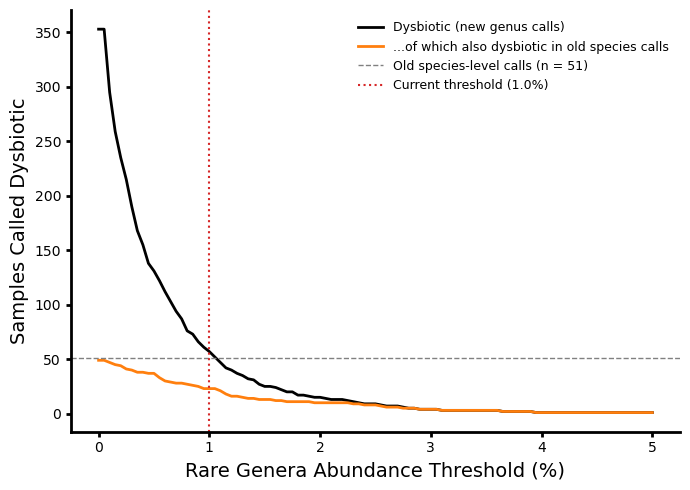

In [7]:
thresholds = np.round(np.arange(0, 5.01, 0.05), 2)
threshold_curve = pd.DataFrame(
    {
        "threshold": thresholds,
        "n_dysbiotic": [
            int((trimmed_metadata["rare_genera_total_abund"] > t).sum())
            for t in thresholds
        ],
        "n_also_old_dysbiotic": [
            int(((trimmed_metadata["rare_genera_total_abund"] > t) & old_dysbiotic).sum())
            for t in thresholds
        ],
    }
)
old_dysbiotic_count = int(old_dysbiotic.sum())

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.plot(
    threshold_curve["threshold"],
    threshold_curve["n_dysbiotic"],
    color="black",
    linewidth=2,
    label="Dysbiotic (new genus calls)",
)
ax.plot(
    threshold_curve["threshold"],
    threshold_curve["n_also_old_dysbiotic"],
    color="tab:orange",
    linewidth=2,
    label="...of which also dysbiotic in old species calls",
)
ax.axhline(
    old_dysbiotic_count,
    color="gray",
    linestyle="dashed",
    linewidth=1,
    label=f"Old species-level calls (n = {old_dysbiotic_count})",
)
ax.axvline(
    rare_genera_abundance_threshold,
    color="tab:red",
    linestyle="dotted",
    linewidth=1.5,
    label=f"Current threshold ({rare_genera_abundance_threshold}%)",
)
plt.xlabel("Rare Genera Abundance Threshold (%)", fontsize=14)
plt.ylabel("Samples Called Dysbiotic", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()

threshold_curve.loc[threshold_curve["threshold"].isin([0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0])]

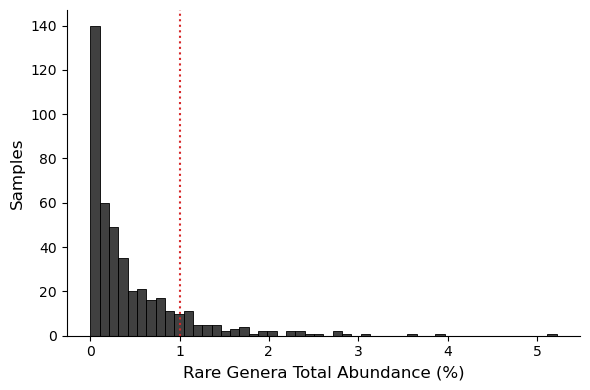

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor("white")
sns.histplot(trimmed_metadata["rare_genera_total_abund"], bins=50, color="black", ax=ax)
ax.axvline(rare_genera_abundance_threshold, color="tab:red", linestyle="dotted")
plt.xlabel("Rare Genera Total Abundance (%)", fontsize=12)
plt.ylabel("Samples", fontsize=12)
sns.despine()
plt.tight_layout()

## Dysbiosis calls

In [9]:
trimmed_metadata["Dysbiosis Status"] = "Not Dysbiotic"
trimmed_metadata.loc[
    trimmed_metadata["rare_genera_total_abund"] > rare_genera_abundance_threshold,
    "Dysbiosis Status",
] = "Dysbiotic"
print(trimmed_metadata["Dysbiosis Status"].value_counts().to_string())

# Save one row per microbiome sample for the PCA / DE notebooks
dysbiosis_calls = sample_summary.assign(
    rare_genera_abundance_threshold=rare_genera_abundance_threshold,
    **{
        "Dysbiosis Status": np.where(
            sample_summary["rare_genera_total_abund"] > rare_genera_abundance_threshold,
            "Dysbiotic",
            "Not Dysbiotic",
        )
    },
)
dysbiosis_calls.index.name = "sampID"
dysbiosis_calls.to_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Generated_data/dysbiosis_calls_recalled_genera.csv"
)

Dysbiosis Status
Not Dysbiotic    375
Dysbiotic         57


### Comparison with old species-level calls and Luke's genus calls

Luke's `lic_16S_gen_plantcore.csv` labels every non-core genus as "rare" (prevalence up to ~78%). His calls are reproduced exactly by "non-core genera ≥ 10% of reads", which is a different rule from the rare-genera definition used here.

In [10]:
luke_calls = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Sept_2026_recalled_genera/lic_16S_gen_dysbiosis.csv",
    index_col="sampleID",
)["Dysbiosis.Status"]
trimmed_metadata["Luke Dysbiosis Status"] = trimmed_metadata["sampID"].map(luke_calls)
trimmed_metadata["Old Species Dysbiosis Status"] = np.where(
    old_dysbiotic, "Dysbiotic", "Not Dysbiotic"
)

print("New genus calls vs old species-level calls:")
display(pd.crosstab(trimmed_metadata["Dysbiosis Status"], trimmed_metadata["Old Species Dysbiosis Status"], margins=True))
print("New genus calls vs Luke's genus calls:")
display(pd.crosstab(trimmed_metadata["Dysbiosis Status"], trimmed_metadata["Luke Dysbiosis Status"], margins=True))

New genus calls vs old species-level calls:


Old Species Dysbiosis Status,Dysbiotic,Not Dysbiotic,All
Dysbiosis Status,,,
Dysbiotic,23,34,57
Not Dysbiotic,28,347,375
All,51,381,432


New genus calls vs Luke's genus calls:


Luke Dysbiosis Status,Dysbiotic,Non-dysbiotic,All
Dysbiosis Status,,,
Dysbiotic,42,15,57
Not Dysbiotic,84,287,371
All,126,302,428


In [11]:
# Check that Luke's calls are "non-core genera >= 10% of reads"
luke_core_table = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Sept_2026_recalled_genera/lic_16S_gen_plantcore.csv"
)
luke_rare = [
    g
    for g in luke_core_table.loc[luke_core_table["corePlant"] == "rare", "Genus"]
    if g in genus_abundance_matrix.columns
]
luke_rare_abund = genus_abundance_matrix[luke_rare].sum(axis=1)
print(
    f"Luke 'rare' genera: {len(luke_rare)}, seasonal prevalence "
    f"{luke_core_table.loc[luke_core_table['corePlant'] == 'rare', 'prevPlant'].min():.3f}"
    f"-{luke_core_table.loc[luke_core_table['corePlant'] == 'rare', 'prevPlant'].max():.3f}"
)
luke_rare_abund.groupby(luke_calls.reindex(luke_rare_abund.index)).agg(["min", "max", "count"])

Luke 'rare' genera: 227, seasonal prevalence 0.005-0.779


,min,max,count
Dysbiosis.Status,,,
Dysbiotic,9.545504,32.667025,126
Non-dysbiotic,1.082473,9.802567,302


## Defense score vs dysbiosis

In [12]:
transcriptome_in_defense_gene_list = trimmed_transcriptome.loc[
    :, trimmed_transcriptome.columns.isin(defense_gene_list["gene"].tolist())
]
summed_zscored_transcriptome = transcriptome_in_defense_gene_list.apply(zscore).sum(
    axis=1
) / len(defense_gene_list)
circadian_metadata_w_load_info = trimmed_metadata.merge(
    summed_zscored_transcriptome.rename("Summed Defense Z Score"),
    left_index=True,
    right_index=True,
)
circadian_metadata_w_load_info.groupby("Dysbiosis Status")["Summed Defense Z Score"].agg(
    ["mean", "median", "count"]
)

,mean,median,count
Dysbiosis Status,,,
Dysbiotic,0.205409,0.146428,57
Not Dysbiotic,-0.031222,-0.149671,375


In [13]:
dysbiotic_scores = circadian_metadata_w_load_info.loc[
    circadian_metadata_w_load_info["Dysbiosis Status"] == "Dysbiotic",
    "Summed Defense Z Score",
]
nondysbiotic_scores = circadian_metadata_w_load_info.loc[
    circadian_metadata_w_load_info["Dysbiosis Status"] == "Not Dysbiotic",
    "Summed Defense Z Score",
]
t_stat, p_value = ttest_ind(dysbiotic_scores, nondysbiotic_scores)
print(f"t = {t_stat:.3f}, P-value: {p_value}")

t = 2.899, P-value: 0.003940621480946715


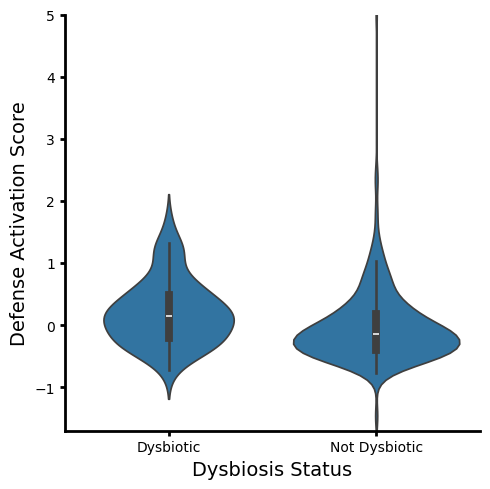

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.violinplot(
    data=circadian_metadata_w_load_info,
    x="Dysbiosis Status",
    y="Summed Defense Z Score",
    order=["Dysbiotic", "Not Dysbiotic"],
    inner="box",
    common_norm=True,
)
plt.xlabel("Dysbiosis Status", fontsize=14)
plt.ylabel("Defense Activation Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-1.7, 5)
plt.tight_layout()

In [15]:
# circadian_metadata_w_load_info.to_csv(
#     "/Users/michael/Library/CloudStorage/GoogleDrive-mikepassalacqua@gmail.com/My Drive/Bergleson Lab Documents/Luke Terrace/All_used_and_generated_terrace_data/Stats_7_28_Files/dysbiosis_status_and_defense_score_recalled_genera.csv",
#     index=True,
# )

Dysbiosis Status
Dysbiotic         12
Not Dysbiotic    108


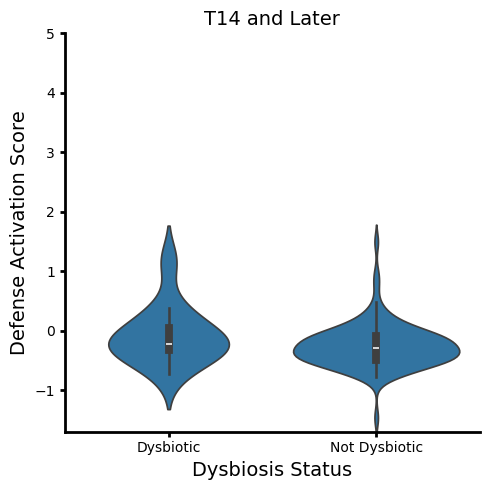

In [16]:
t14_and_later = circadian_metadata_w_load_info.loc[
    pd.to_numeric(
        circadian_metadata_w_load_info["timepoint"]
        .astype(str)
        .str.extract(r"(\d+)", expand=False),
        errors="coerce",
    )
    >= 14
]
print(t14_and_later.groupby("Dysbiosis Status")["Summed Defense Z Score"].count().to_string())

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.violinplot(
    data=t14_and_later,
    x="Dysbiosis Status",
    y="Summed Defense Z Score",
    order=["Dysbiotic", "Not Dysbiotic"],
    inner="box",
    common_norm=True,
)
plt.xlabel("Dysbiosis Status", fontsize=14)
plt.ylabel("Defense Activation Score", fontsize=14)
plt.title("T14 and Later", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-1.7, 5)
plt.tight_layout()

Experiment Type         Dysbiosis Status
Circadian Experiment 1  Dysbiotic            8
                        Not Dysbiotic       96
Circadian Experiment 2  Dysbiotic            6
                        Not Dysbiotic       98


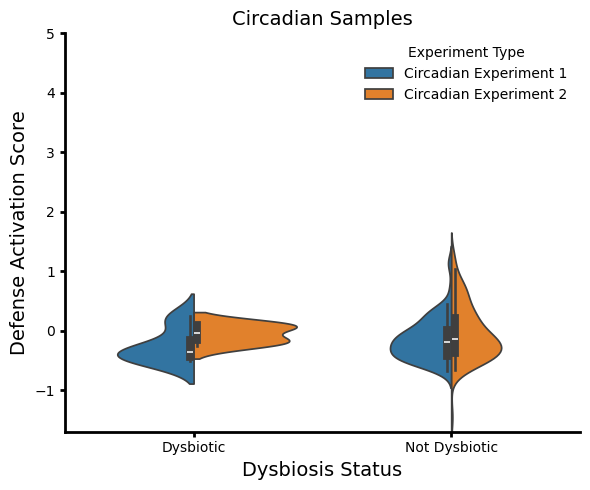

In [17]:
circadian_only = circadian_metadata_w_load_info.loc[
    circadian_metadata_w_load_info["Experiment Type"].isin(
        ["Circadian Experiment 1", "Circadian Experiment 2"]
    )
]
print(circadian_only.groupby(["Experiment Type", "Dysbiosis Status"]).size().to_string())

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor("white")
ax = sns.violinplot(
    data=circadian_only,
    x="Dysbiosis Status",
    y="Summed Defense Z Score",
    hue="Experiment Type",
    order=["Dysbiotic", "Not Dysbiotic"],
    inner="box",
    common_norm=True,
    split=True,
)
plt.xlabel("Dysbiosis Status", fontsize=14)
plt.ylabel("Defense Activation Score", fontsize=14)
plt.title("Circadian Samples", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(-1.7, 5)
plt.legend(title="Experiment Type", frameon=False)
plt.tight_layout()

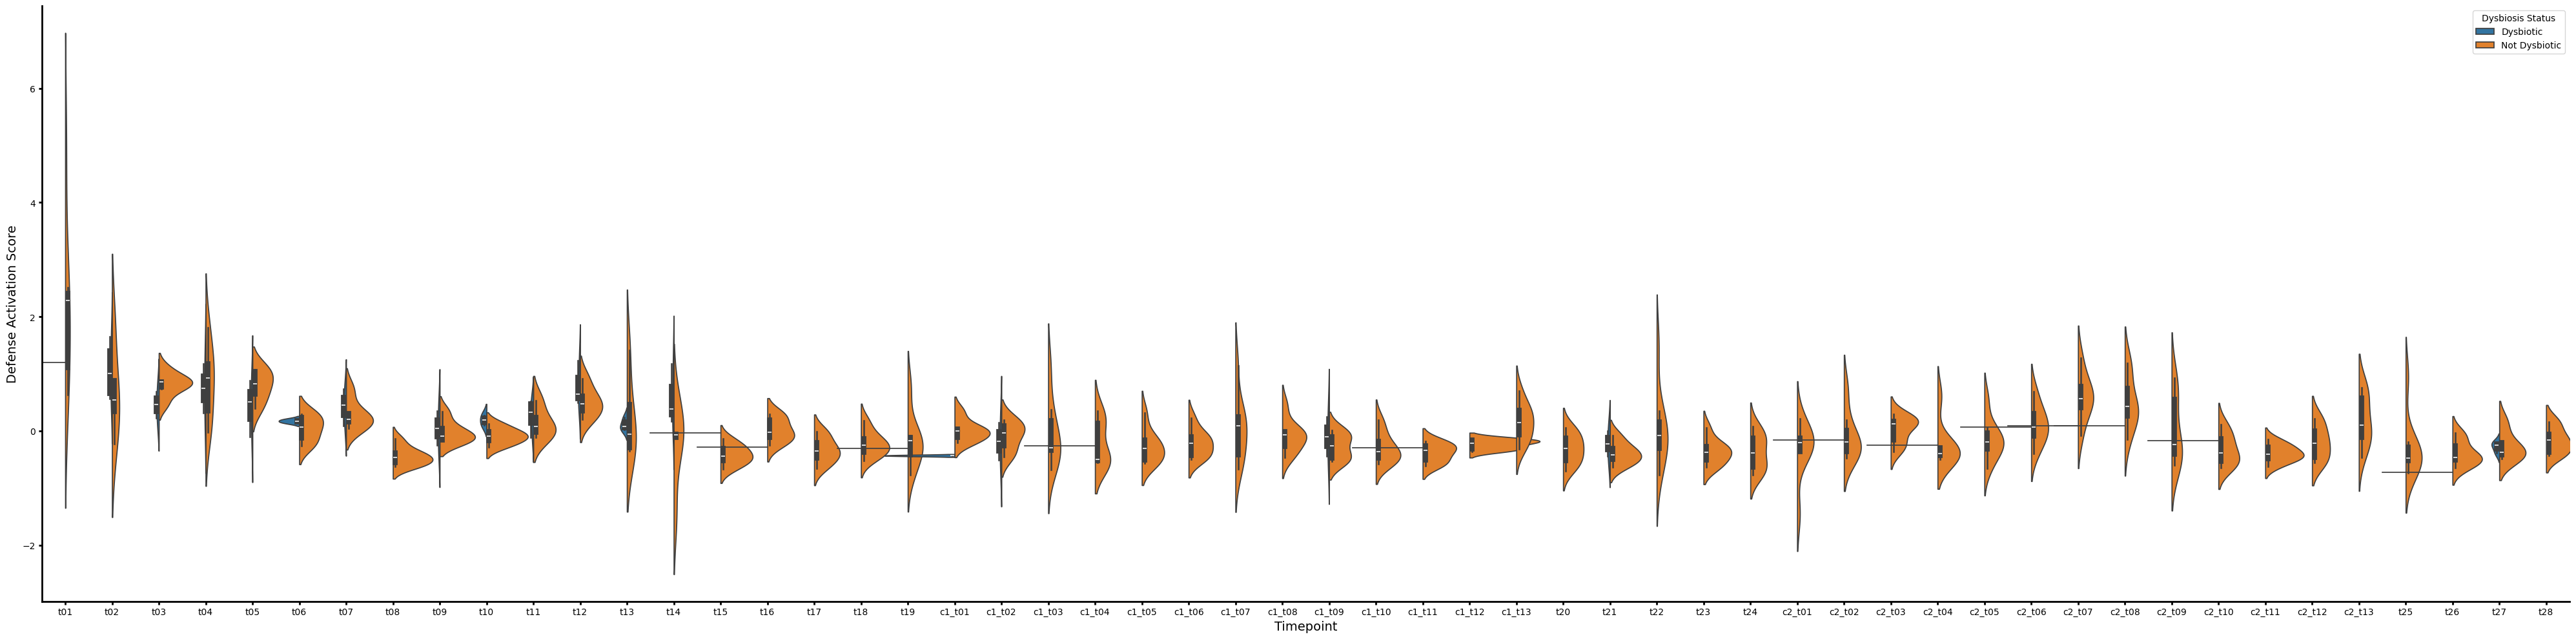

In [18]:
fig, ax = plt.subplots(figsize=(40, 10))
fig.patch.set_facecolor("white")
ax = sns.violinplot(
    data=circadian_metadata_w_load_info.sort_values("Date and Time"),
    x="timepoint",
    y="Summed Defense Z Score",
    hue="Dysbiosis Status",
    hue_order=["Dysbiotic", "Not Dysbiotic"],
    width=3,
    split=True,
    inner="box",
)
plt.xlabel("Timepoint", fontsize=14)
plt.ylabel("Defense Activation Score", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()